In [1]:
%load_ext autoreload
%autoreload 2

In [26]:
%reload_ext autoreload

In [2]:
import pickle as pkl
import numpy as np
from torch.utils.data import DataLoader, random_split

from plots import *
from utils import *
from dataset import *
from vae import *

In [3]:
#on runai
with open('/mydata/cope/mirco/data/ssp585_time_series.pkl', 'rb') as f:
    cope_data = pkl.load(f)

In [3]:
#on local
with open('cope_data/ssp585_time_series.pkl', 'rb') as f:
    cope_data = pkl.load(f)

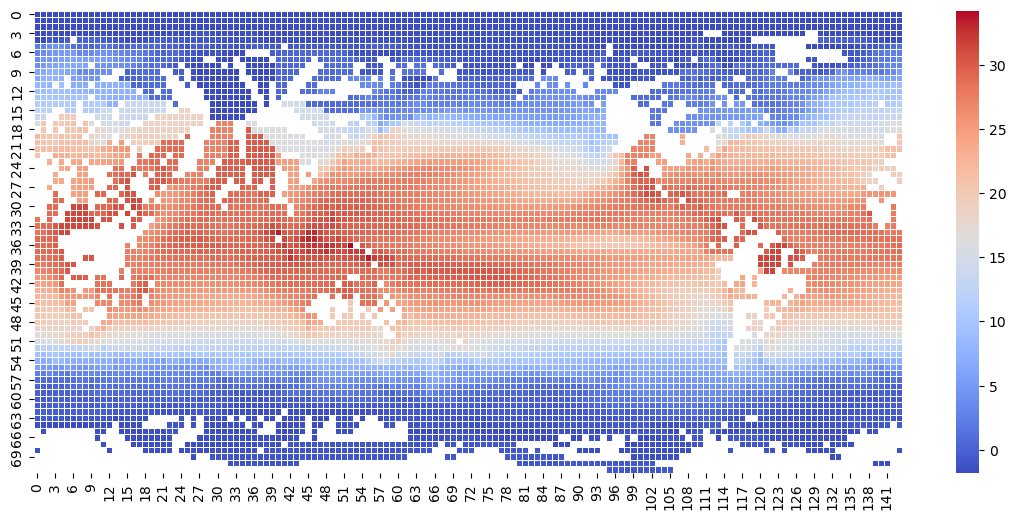

In [5]:
plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

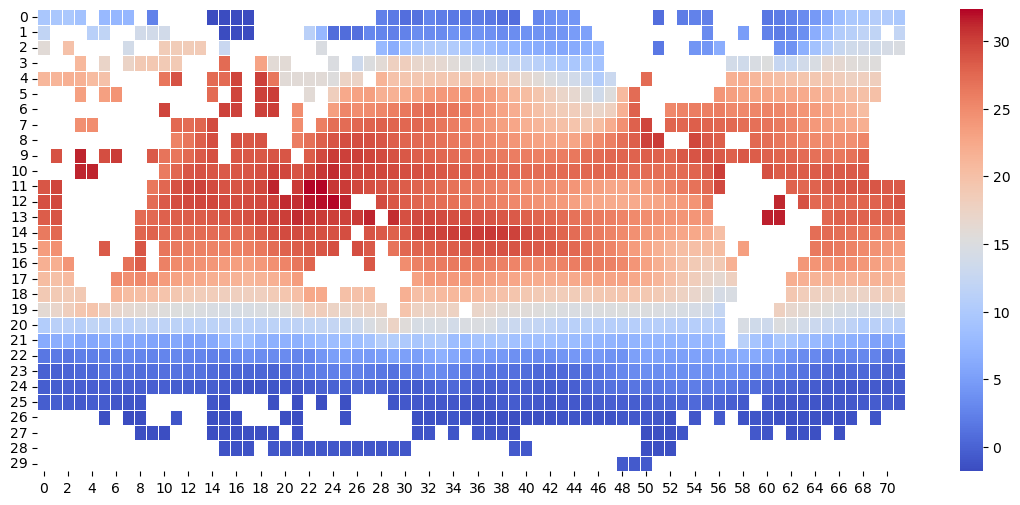

In [4]:
prune(cope_data, min_runs=5)
cut_lat(cope_data, max_lat=60)
downscale(cope_data)

plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

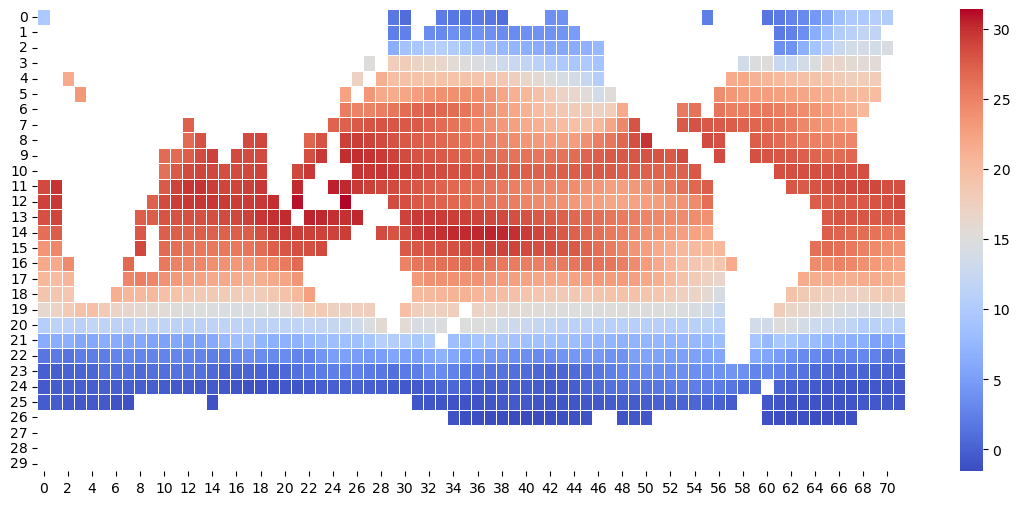

In [5]:
union_nan_mask = find_union_nan_mask(cope_data)
inpute(cope_data, union_nan_mask)

plot_heatmap(cope_data, 'ICON-ESM-LR', 'r1i1p1f1', 1980)

In [7]:
np.array(cope_data['ICON-ESM-LR']['r1i1p1f1']).shape

In [8]:
X, Y = extract_per_timeserie(cope_data, union_nan_mask, r=[-10, 10])
print(X.shape, Y.shape)

(612, 44472) (612, 44472)


In [ ]:
grid_timeserie = from_flat_to_timegrid(X[0], union_nan_mask)
grid_timeserie.shape
plot_grid(grid_timeserie[1])

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [10]:
batch_size = 16

cope_dataset = CopeDataset(samples=X, labels=Y)

train_dataset, test_dataset = random_split(cope_dataset, [0.8, 0.2])

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [10]:
lr = 1.5e-3
epochs = 40

model = basic_VAE(input_dim=44472, hidden_dim=500, latent_dim=100).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)


print("Start training basic VAE...")
model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, y) in enumerate(train_dataloader):
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mean, logvar = model(x)
        loss = model.loss(x_hat, y, mean, logvar)
        
        overall_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    print("Epoch", epoch + 1, "complete !", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

In [56]:
lr = 1e-3
epochs = 40

model = VAE(input_dim=44472, hidden_dim=500, latent_dim=100).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

print("Start training VAE...")
model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, y) in enumerate(train_dataloader):
        x = x.to(device)

        optimizer.zero_grad()

        x_hat, mean, var = model(x)
        loss = model.loss(x_hat, y, mean, var)
        
        overall_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    print("Epoch", epoch + 1, "complete !", "\tAverage Loss: ", overall_loss / (batch_idx*batch_size))
    
print("Finish!!")

Start training VAE...
Epoch 1 complete ! 	Average Loss:  10228.03514811198
Epoch 2 complete ! 	Average Loss:  4905.682462565104
Epoch 3 complete ! 	Average Loss:  4519.821476236979
Epoch 4 complete ! 	Average Loss:  4569.662727864584
Epoch 5 complete ! 	Average Loss:  4299.883479817709
Epoch 6 complete ! 	Average Loss:  3555.5994954427083
Epoch 7 complete ! 	Average Loss:  2812.114957682292
Epoch 8 complete ! 	Average Loss:  2362.030839029948
Epoch 9 complete ! 	Average Loss:  2112.8172281901043
Epoch 10 complete ! 	Average Loss:  1944.2853719075522
Epoch 11 complete ! 	Average Loss:  1838.0711100260417
Epoch 12 complete ! 	Average Loss:  1781.8019592285157
Epoch 13 complete ! 	Average Loss:  1725.2618408203125
Epoch 14 complete ! 	Average Loss:  1702.3457458496093
Epoch 15 complete ! 	Average Loss:  1680.697412109375
Epoch 16 complete ! 	Average Loss:  1668.038106282552
Epoch 17 complete ! 	Average Loss:  1648.3648885091145
Epoch 18 complete ! 	Average Loss:  1618.1938354492188
Epoch 

In [32]:
model.eval()

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)
        x_hat, _, _ = model(x)
        x_hat.detach()

        break

x, x_hat, y = x.numpy()[0], x_hat.numpy()[0], y.numpy()[0]

In [33]:
print(x.shape)
print(x_hat.shape)
print(y.shape)

(44472,)
(44472,)
(44472,)


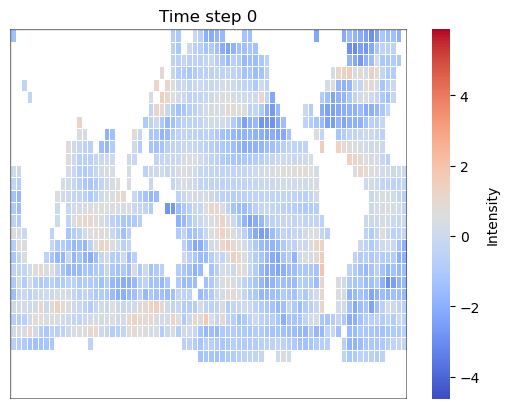

In [42]:
a = get_animated_timeserie(x, union_nan_mask)
a.save('vae_x.gif', writer='pillow', fps=1)

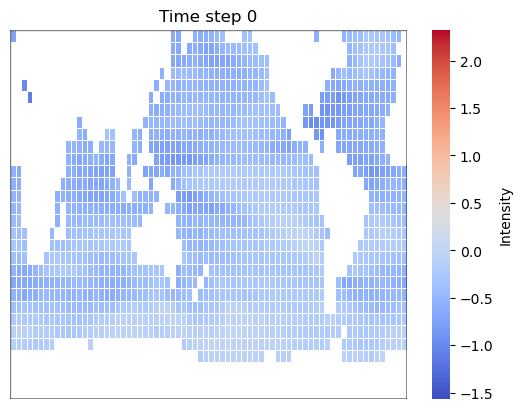

In [43]:
a = get_animated_timeserie(x_hat, union_nan_mask)
a.save('vae_x_hat.gif', writer='pillow', fps=1)

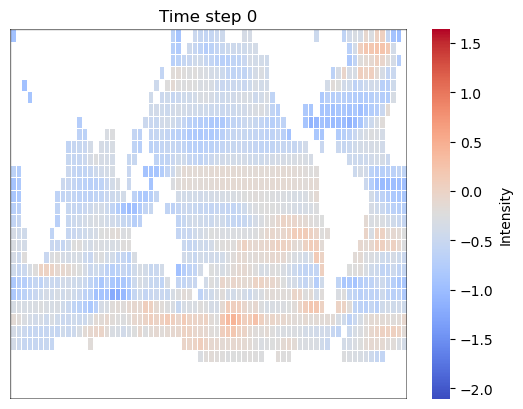

In [44]:
a = get_animated_timeserie(y, union_nan_mask)
a.save('vae_y.gif', writer='pillow', fps=1)

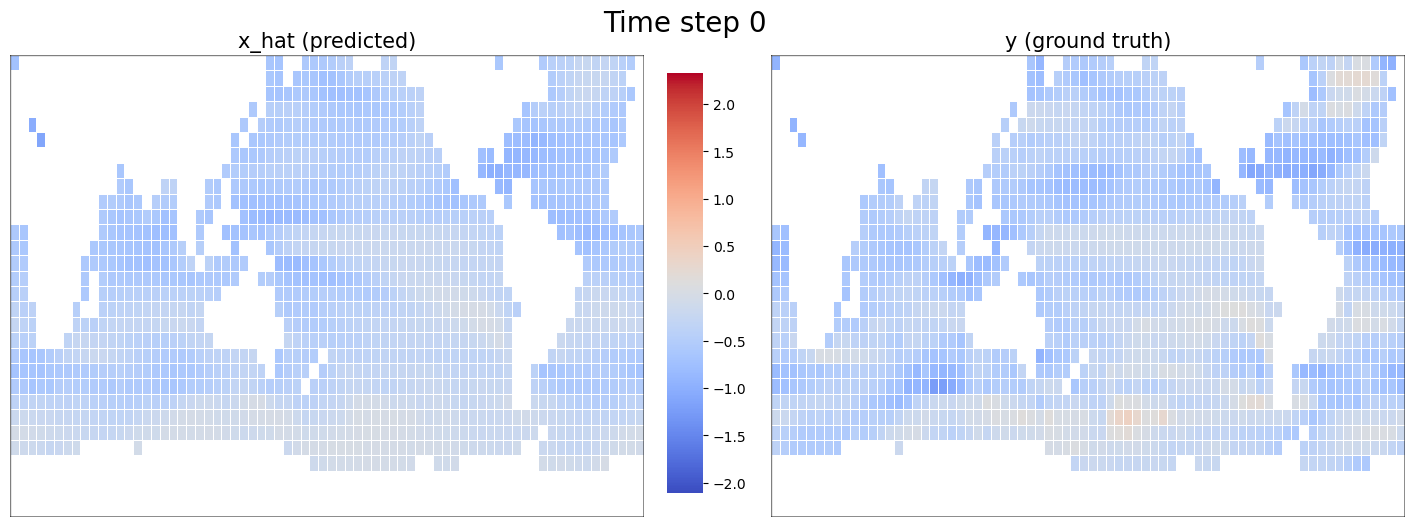

In [49]:
a = get_duo_animated_timeserie(x_hat, y, union_nan_mask)
a.save('vae_pred_and_truth.gif', writer='pillow', fps=1)

In [50]:
n_samples = 100

model.eval()
with torch.no_grad():
    for batch_idx, (x, y) in enumerate(test_dataloader):
        x = x.to(device)[0]
        samples = model.sample(x, n_samples)

        break

In [53]:
samples[0].shape

torch.Size([44472])

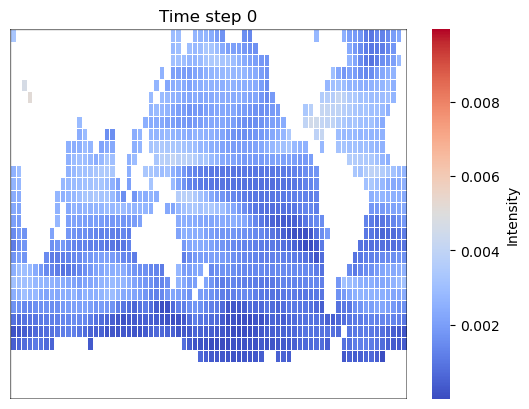

In [62]:
conf_int = get_confidence_interval_grid_timeserie(samples)
a = get_animated_timeserie(conf_int, union_nan_mask)
a.save('vae_confidence_interval.gif', writer='pillow', fps=1)


In [11]:
epochs = 30
lrs = [1e-3, 1.5e-3, 2e-3]
hidden_dims = [500, 1000, 1500]
latent_dims = [100, 200, 300]
configurations = len(lrs)*len(hidden_dims)*len(latent_dims)

batch_size = 16

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

ith = 1

print('Begin cross validation...\n')

all_mse_losses = {}
all_nmse_losses = {}
for lr in lrs:
    for hidden_dim in hidden_dims:
        for latent_dim in latent_dims:
            model = VAE(input_dim=44472, hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)
            mse_losses, nmse_losses = VAE_LOOCV(cope_data, union_nan_mask, model, epochs, batch_size, lr)

            all_mse_losses[f'vae_{lr}_{epochs}'] = mse_losses
            all_nmse_losses[f'vae_{lr}_{epochs}'] = nmse_losses
            
            print(f'Finished configuration {ith}/{configurations}')

            ith += 1

print('\nFinished training !\n')

Using device: cpu
Begin cross validation...



TypeError: VAE_LOOCV() takes from 4 to 5 positional arguments but 6 were given